# 08 · Benchmarking & Configurable Scoring

The v0.6 milestone makes the transition-risk score **contextual and configurable**:

1. **Scoring profiles** — load component weights from a versioned config file or a built-in profile.
2. **Peer-group scoring** — min-max scale components *within* a peer group (EU, OECD, income tier) so risk is relative to comparable economies.
3. **Benchmark report** — rank, percentile, and gaps to the peer median and leader.

> Absolute, world-wide scoring penalises poorer or more industrial economies. Benchmarking within peers is a fairer screening lens — still a screening signal, never a causal judgement.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


def find_repo_root(start: Path | None = None) -> Path:
    """Walk upwards until the directory containing pyproject.toml is found."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return here


REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / "data" / "raw"
DB_PATH = REPO_ROOT / "data" / "processed" / "carbon_transition.duckdb"
MARTS_DIR = REPO_ROOT / "data" / "processed" / "marts"
print(f"Repository root: {REPO_ROOT}")


Repository root: C:\Users\diogo\work_code\portfolio\carbon-transition-duckdb-lab


In [2]:
from carbon_transition_duckdb.config import ProjectPaths
from carbon_transition_duckdb.pipeline import build_duckdb_lakehouse, load_transition_mart
from carbon_transition_duckdb.risk.scoring import filter_entities
from carbon_transition_duckdb.sample_data import generate_synthetic_owid_data

if not DB_PATH.exists():
    generate_synthetic_owid_data(RAW_DIR, start_year=2010, end_year=2024)
    build_duckdb_lakehouse(
        ProjectPaths(raw_dir=RAW_DIR, database=DB_PATH, export_dir=MARTS_DIR)
    )

mart = filter_entities(load_transition_mart(DB_PATH))
print(f"Mart: {mart.shape[0]} rows, {mart['country'].nunique()} countries")


Mart: 75 rows, 5 countries


## 1. Scoring profiles

Profiles are explicit, validated weightings. Built-ins ship with the package; custom ones load from YAML/JSON in `profiles/`.

In [3]:
from carbon_transition_duckdb.risk.profiles import BUILTIN_PROFILES, get_profile

rows = []
for name, profile in BUILTIN_PROFILES.items():
    w = profile.weights
    rows.append({
        'profile': name,
        'co2_trend': w.co2_trend, 'co2_per_capita': w.co2_per_capita,
        'carbon_intensity': w.carbon_intensity, 'fossil_share': w.fossil_share,
        'renewable_gap': w.renewable_gap,
    })
file_profile = get_profile(str(REPO_ROOT / 'profiles' / 'renewables_focused.yaml'))
print('Loaded from file:', file_profile.name, '-', file_profile.description)
pd.DataFrame(rows).set_index('profile')

Loaded from file: renewables_focused - Emphasise the renewable electricity gap and fossil share.


,co2_trend,co2_per_capita,carbon_intensity,fossil_share,renewable_gap
profile,,,,,
default,0.3,0.20,0.20,0.2,0.1
trend_focused,0.4,0.15,0.15,0.2,0.1
renewables_focused,0.2,0.15,0.15,0.2,0.3


## 2. Peer-group benchmarking

The synthetic countries are fictional, so we treat them as one peer group to demonstrate the mechanics. On real OWID data, pass `group='eu'`, `'oecd'`, or an income tier.

In [4]:
from carbon_transition_duckdb.benchmark import benchmark_group

bench = benchmark_group(mart, group=None, weights=get_profile('default').weights)
bench

,country,transition_risk_score,risk_rank,peer_percentile,peer_median,gap_to_median,gap_to_leader
0,Deltora,68.76,1,0.0,50.99,17.77,58.91
1,Borealia,58.12,2,25.0,50.99,7.13,48.27
2,Atlantis,50.99,3,50.0,50.99,0.00,41.14
3,Estavia,15.39,4,75.0,50.99,-35.60,5.54
4,Cyrenia,9.85,5,100.0,50.99,-41.14,0.00


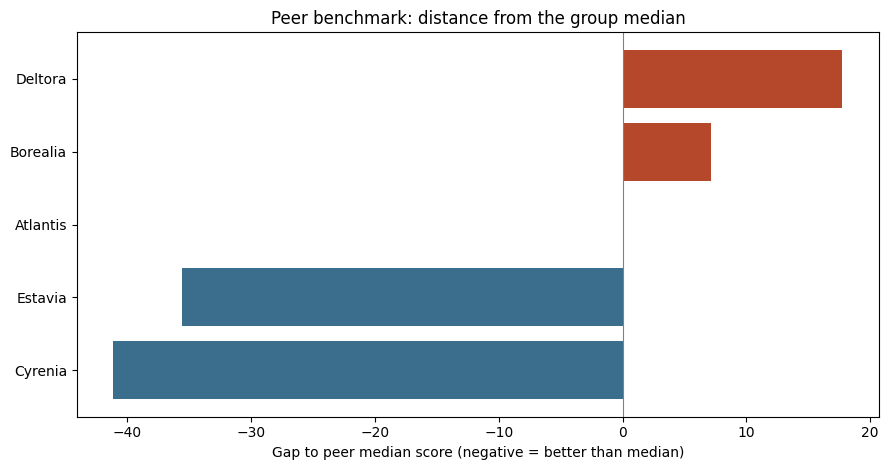

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ordered = bench.sort_values('transition_risk_score')
colors = ['#3b6e8c' if g <= 0 else '#b5482a' for g in ordered['gap_to_median']]
ax.barh(ordered['country'], ordered['gap_to_median'], color=colors)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Gap to peer median score (negative = better than median)')
ax.set_title('Peer benchmark: distance from the group median')
fig.tight_layout()
plt.show()

## 3. How the profile changes the ranking

Re-benchmarking under a different profile shifts the scores and can reorder the middle of the table — making the weighting choice explicit.

In [6]:
compare = bench[['country']].copy()
for name in ['default', 'trend_focused', 'renewables_focused']:
    b = benchmark_group(mart, group=None, weights=get_profile(name).weights)
    compare = compare.merge(
        b[['country', 'transition_risk_score']].rename(
            columns={'transition_risk_score': name}),
        on='country',
    )
compare.set_index('country').round(1)

,default,trend_focused,renewables_focused
country,,,
Deltora,68.8,66.5,76.4
Borealia,58.1,53.3,63.2
Atlantis,51.0,49.6,52.3
Estavia,15.4,16.7,15.3
Cyrenia,9.8,13.1,6.6


## Takeaways

- Scoring profiles turn the weighting into versioned, auditable config — no hidden constants.
- Peer-group benchmarking scales each component within comparable economies, a fairer lens than a single global ranking.
- The benchmark report (rank, percentile, gap-to-median/leader) is a transparent way to ask *"where does this country sit among its peers?"*
- On real OWID data, `group='eu'` / `'oecd'` / income tiers make these comparisons concrete.